In [ ]:
# ==========================
# Import Libraries & Ignore Warnings
# ==========================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Libraries imported successfully
TensorFlow version: 2.19.0
Num GPUs Available:  1


In [ ]:
# ==========================
# Load Dataset from KaggleHub
# ==========================

import kagglehub

# Download latest version of dataset
path = kagglehub.dataset_download("techsash/waste-classification-data")
print("Path to dataset files:", path)

# The dataset structure looks like:
# DATASET/
# ├── TRAIN/
# │   ├── O/
# │   └── R/
# └── TEST/
#     ├── O/
#     └── R/

train_dir = os.path.join(path, "DATASET/TRAIN")
test_dir  = os.path.join(path, "DATASET/TEST")

print("Train dir:", train_dir)
print("Test dir:", test_dir)

# Quick check - number of images per class
for folder in ["O", "R"]:
    print(f"Train {folder}: {len(os.listdir(os.path.join(train_dir, folder)))} images")
    print(f"Test  {folder}: {len(os.listdir(os.path.join(test_dir, folder)))} images")

Path to dataset files: /kaggle/input/waste-classification-data
Train dir: /kaggle/input/waste-classification-data/DATASET/TRAIN
Test dir: /kaggle/input/waste-classification-data/DATASET/TEST
Train O: 12565 images
Test  O: 1401 images
Train R: 9999 images
Test  R: 1112 images


In [ ]:
# ==========================
# Data Overview
# ==========================

import matplotlib.image as mpimg
import random

# Count images per class
train_counts = {
    "Organic": len(os.listdir(os.path.join(train_dir, "O"))),
    "Recyclable": len(os.listdir(os.path.join(train_dir, "R")))
}
test_counts = {
    "Organic": len(os.listdir(os.path.join(test_dir, "O"))),
    "Recyclable": len(os.listdir(os.path.join(test_dir, "R")))
}

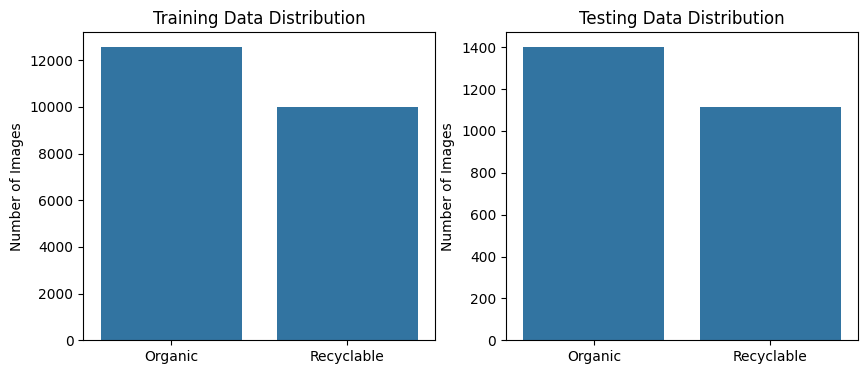

In [ ]:
# ---- Plot class distribution ----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")

plt.subplot(1,2,2)
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()))
plt.title("Testing Data Distribution")
plt.ylabel("Number of Images")

plt.show()

 Sample Organic Images:


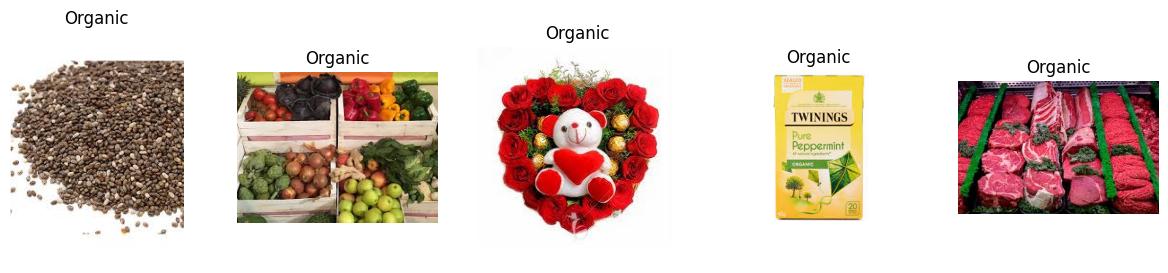

In [ ]:
# ---- Show random sample images ----
def show_samples(folder, label, n=5):
    plt.figure(figsize=(15,3))
    img_files = random.sample(os.listdir(folder), n)
    for i, img_name in enumerate(img_files):
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label)
    plt.show()

print(" Sample Organic Images:")
show_samples(os.path.join(train_dir, "O"), "Organic")

 Sample Recyclable Images:


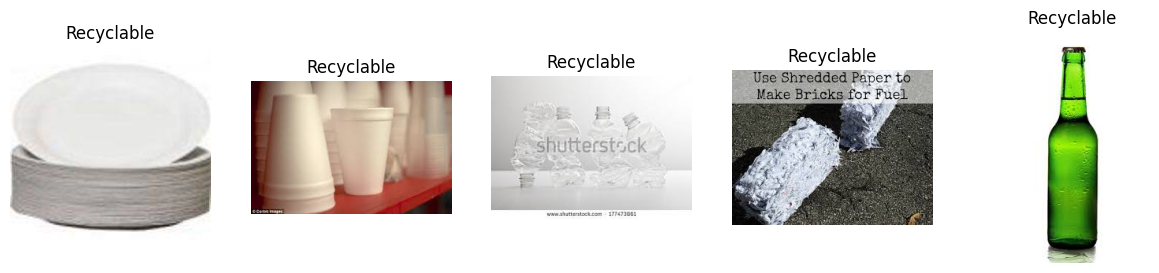

In [ ]:
print(" Sample Recyclable Images:")
show_samples(os.path.join(train_dir, "R"), "Recyclable")

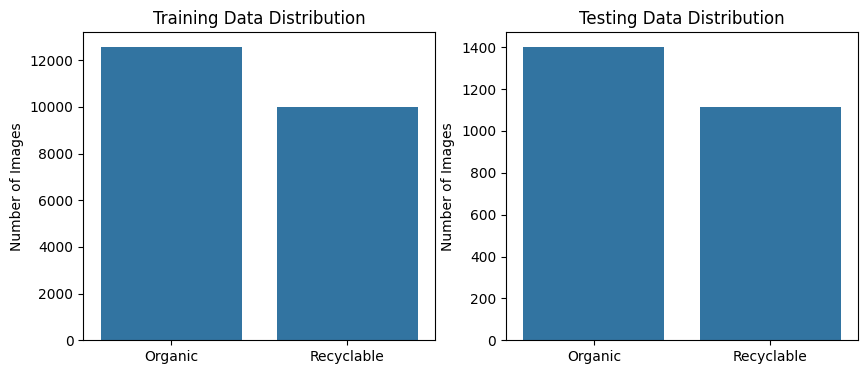

In [ ]:
# ==========================
# Exploratory Data Analysis (EDA)
# ==========================
import cv2
from tqdm import tqdm

#  Class Distribution (already plotted earlier, repeating for clarity)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")

plt.subplot(1,2,2)
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()))
plt.title("Testing Data Distribution")
plt.ylabel("Number of Images")
plt.show()

Scanning R: 100%|██████████| 9999/9999 [01:13<00:00, 135.39it/s]


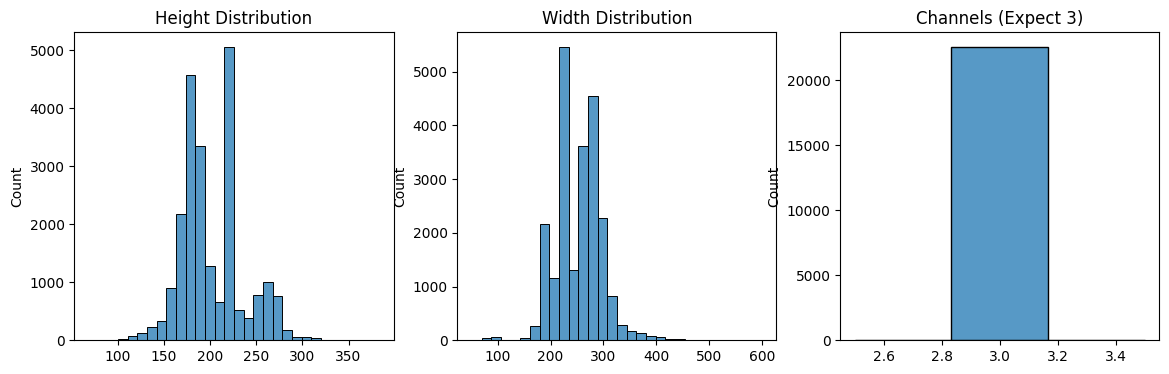

 Avg Height: 203.7, Avg Width: 252.3, Channels: {3}


In [ ]:
# Image Dimension Analysis
def get_image_shapes(folder):
    shapes = []
    for cls in ["O", "R"]:
        cls_path = os.path.join(folder, cls)
        for img_name in tqdm(os.listdir(cls_path), desc=f"Scanning {cls}"):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    shapes.append(img.shape)
            except:
                pass
    return shapes

train_shapes = get_image_shapes(train_dir)
heights = [s[0] for s in train_shapes]
widths = [s[1] for s in train_shapes]
channels = [s[2] for s in train_shapes]

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); sns.histplot(heights, bins=30); plt.title("Height Distribution")
plt.subplot(1,3,2); sns.histplot(widths, bins=30); plt.title("Width Distribution")
plt.subplot(1,3,3); sns.histplot(channels, bins=3); plt.title("Channels (Expect 3)")
plt.show()

print(f" Avg Height: {np.mean(heights):.1f}, Avg Width: {np.mean(widths):.1f}, Channels: {set(channels)}")

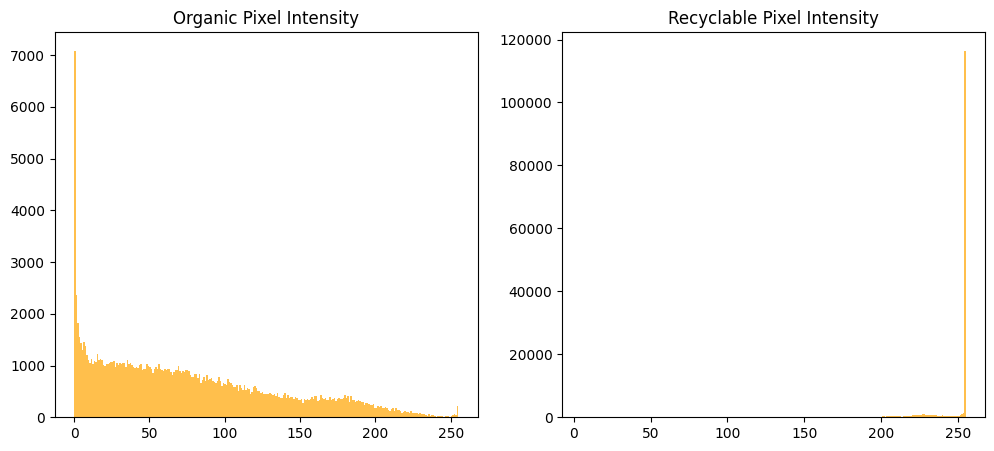

In [ ]:
#  Pixel Intensity Distribution
sample_imgs = []
for cls in ["O", "R"]:
    cls_path = os.path.join(train_dir, cls)
    img_path = os.path.join(cls_path, random.choice(os.listdir(cls_path)))
    img = cv2.imread(img_path)
    sample_imgs.append(img)

plt.figure(figsize=(12,5))
for i, img in enumerate(sample_imgs):
    plt.subplot(1,2,i+1)
    plt.hist(img.ravel(), bins=256, color='orange', alpha=0.7)
    plt.title(["Organic", "Recyclable"][i] + " Pixel Intensity")
plt.show()

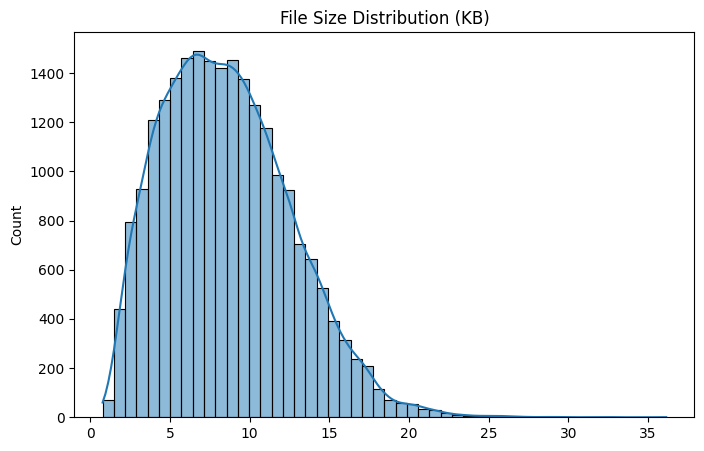

 Avg file size: 8.60 KB, Max: 36.15 KB, Min: 0.77 KB


In [ ]:
#  File Size Distribution
file_sizes = []
for cls in ["O", "R"]:
    cls_path = os.path.join(train_dir, cls)
    for f in os.listdir(cls_path):
        file_sizes.append(os.path.getsize(os.path.join(cls_path, f)) / 1024)  # in KB

plt.figure(figsize=(8,5))
sns.histplot(file_sizes, bins=50, kde=True)
plt.title("File Size Distribution (KB)")
plt.show()

print(f" Avg file size: {np.mean(file_sizes):.2f} KB, Max: {np.max(file_sizes):.2f} KB, Min: {np.min(file_sizes):.2f} KB")

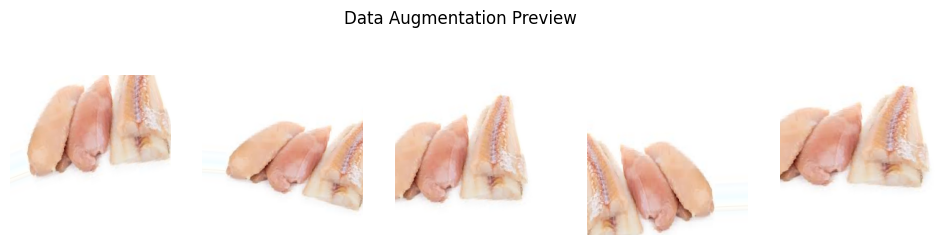

In [ ]:
#  Augmentation Preview
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

sample_path = os.path.join(train_dir, "O", random.choice(os.listdir(os.path.join(train_dir, "O"))))
img = tf.keras.utils.load_img(sample_path, target_size=(224,224))
x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)

plt.figure(figsize=(12,3))
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(1,5,i+1)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i == 5: break
plt.suptitle("Data Augmentation Preview")
plt.show()

In [ ]:
# ==========================
# Data Preprocessing Pipeline
# ==========================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size (EfficientNet prefers 224x224)
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=20,           # Rotate images up to 20 degrees
    width_shift_range=0.2,       # Shift width
    height_shift_range=0.2,      # Shift height
    shear_range=0.15,            # Shear transformation
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Flip horizontally
    fill_mode="nearest"          # Fill missing pixels after transformation
)

# Only rescaling for Test (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"   # since we have 2 classes
)

# Load testing images
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Class mapping
print("Class Indices:", train_generator.class_indices)

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Class Indices: {'O': 0, 'R': 1}


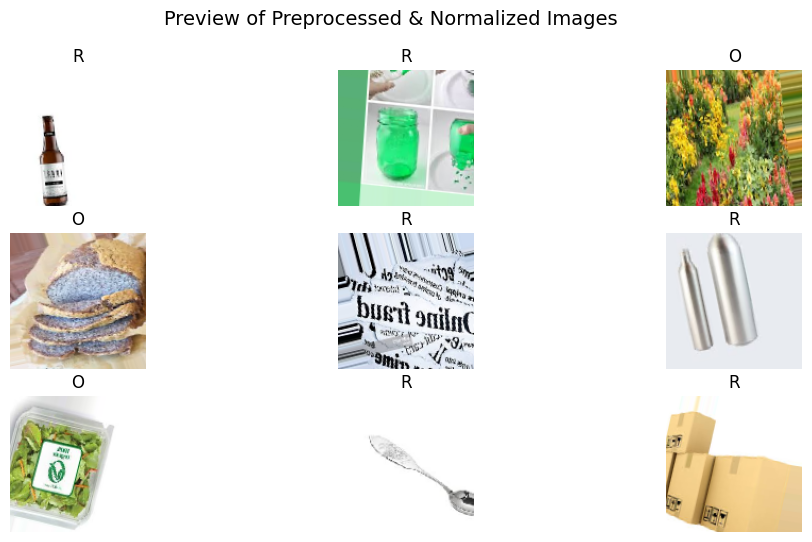

Image shape: (128, 128, 3)
Pixel range: min = 0.0 , max = 1.0


In [ ]:
# ==========================
# Data Preview after Preprocessing & Normalization
# ==========================

# Get a batch of training images
sample_imgs, sample_labels = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(9):  # show 9 images
    plt.subplot(3,3,i+1)
    plt.imshow(sample_imgs[i])  # already rescaled (0–1) by ImageDataGenerator
    label = list(train_generator.class_indices.keys())[np.argmax(sample_labels[i])]
    plt.title(label)
    plt.axis("off")

plt.suptitle("Preview of Preprocessed & Normalized Images", fontsize=14)
plt.show()

print("Image shape:", sample_imgs[0].shape)
print("Pixel range: min =", sample_imgs.min(), ", max =", sample_imgs.max())

# Deep learning model

In [ ]:
# ==========================
# Build a Lighter & Faster CNN Model
# ==========================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_cnn = Sequential([
    # Block 1
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    # Block 2
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    # Block 3
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),   # less dropout since model is smaller
    Dense(2, activation='softmax')  # 2 classes: Organic, Recyclable
])

# Compile model
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 63, 63, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,042 (3.15 MB)

 Trainable params: 826,818 (3.15 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# ==========================
# Train the Model
# ==========================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 5

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = model_cnn.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 149s 106ms/step - accuracy: 0.8113 - loss: 0.4440 - val_accuracy: 0.8559 - val_loss: 0.3806
Epoch 2/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 127s 90ms/step - accuracy: 0.8185 - loss: 0.4284 - val_accuracy: 0.8747 - val_loss: 0.3266
Epoch 3/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 138s 98ms/step - accuracy: 0.8269 - loss: 0.4162 - val_accuracy: 0.8476 - val_loss: 0.3843
Epoch 4/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 130s 89ms/step - accuracy: 0.8283 - loss: 0.4083 - val_accuracy: 0.9013 - val_loss: 0.2804
Epoch 5/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.8367 - loss: 0.3910 - val_accuracy: 0.8205 - val_loss: 0.3984


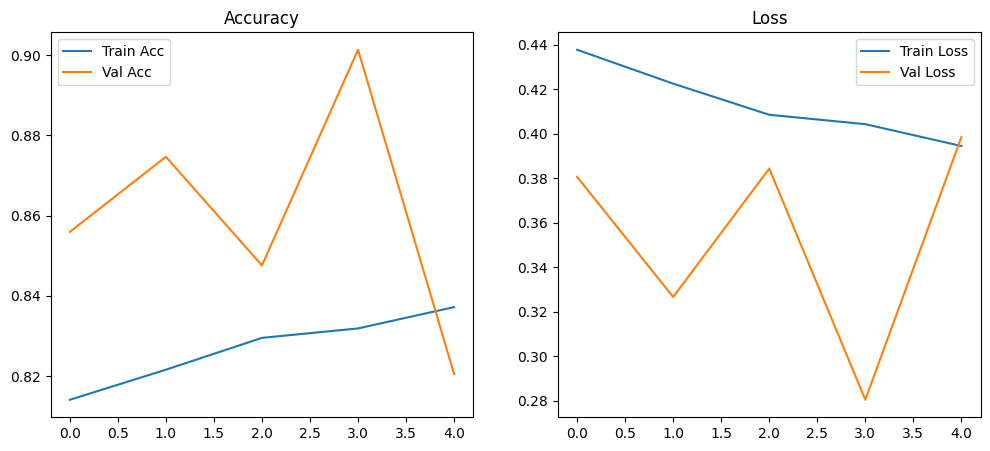

In [ ]:
# ==========================
# Plot Training History
# ==========================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
 Classification Report:
              precision    recall  f1-score   support

           O       0.88      0.96      0.92      1401
           R       0.94      0.83      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.89      0.90      2513
weighted avg       0.90      0.90      0.90      2513



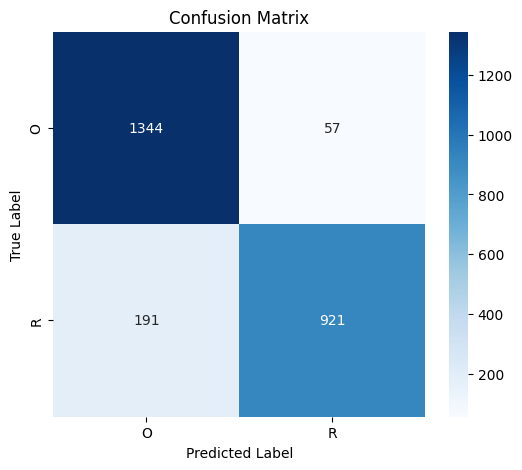

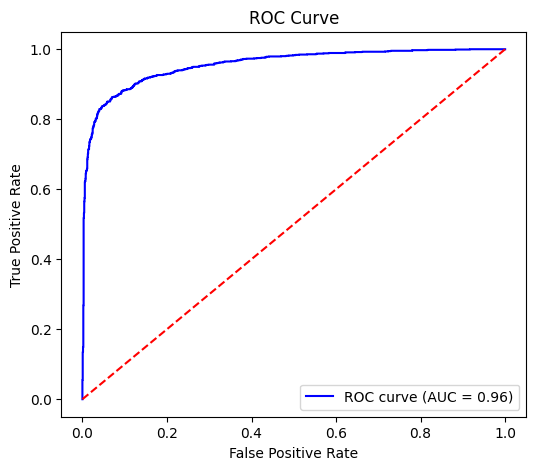

In [ ]:
# ==========================
# Evaluate Model (Classification Report, Confusion Matrix, ROC AUC)
# ==========================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# Get predictions
y_true = test_generator.classes
y_prob = model_cnn.predict(test_generator)   # probabilities
y_pred = y_prob.argmax(axis=1)               # predicted labels

# --- Classification Report ---
print(" Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- ROC Curve & AUC ---
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])   # class "1" (Recyclable)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Neural network model

In [ ]:
# ==========================
# Build a Neural Network Model (ANN)
# ==========================
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model_ann = Sequential([
    Flatten(input_shape=(128,128,3)),   # flatten image into 1D vector
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')   # 2 classes
])

# Compile model
model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,330,818 (96.63 MB)

 Trainable params: 25,330,818 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================
# Train the ANN
# ==========================
EPOCHS = 5

history_ann = model_ann.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 125s 86ms/step - accuracy: 0.5710 - loss: 4.1571 - val_accuracy: 0.5579 - val_loss: 0.5917
Epoch 2/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 118s 83ms/step - accuracy: 0.5654 - loss: 0.6588 - val_accuracy: 0.7445 - val_loss: 0.5840
Epoch 3/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 117s 83ms/step - accuracy: 0.6053 - loss: 0.6352 - val_accuracy: 0.7823 - val_loss: 0.5646
Epoch 4/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.6343 - loss: 0.6212 - val_accuracy: 0.8647 - val_loss: 0.5323
Epoch 5/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 139s 84ms/step - accuracy: 0.6328 - loss: 0.6196 - val_accuracy: 0.8496 - val_loss: 0.5461


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
 Classification Report (ANN):
              precision    recall  f1-score   support

           O       0.87      0.86      0.86      1401
           R       0.82      0.84      0.83      1112

    accuracy                           0.85      2513
   macro avg       0.85      0.85      0.85      2513
weighted avg       0.85      0.85      0.85      2513



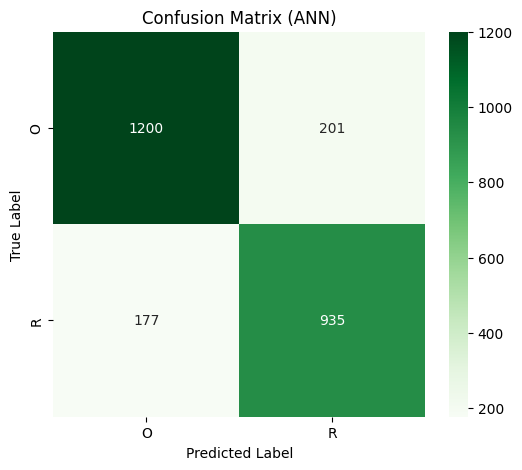

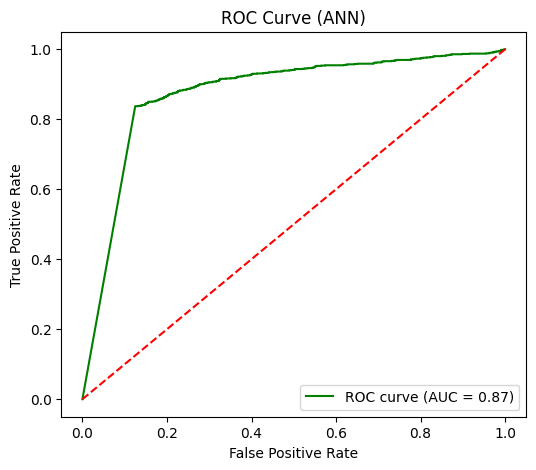

In [ ]:
# ==========================
# Evaluate ANN
# ==========================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Predictions
y_true = test_generator.classes
y_prob = model_ann.predict(test_generator)
y_pred = y_prob.argmax(axis=1)

# --- Classification Report ---
print(" Classification Report (ANN):")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.title("Confusion Matrix (ANN)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- ROC Curve & AUC ---
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="green", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ANN)")
plt.legend(loc="lower right")
plt.show()

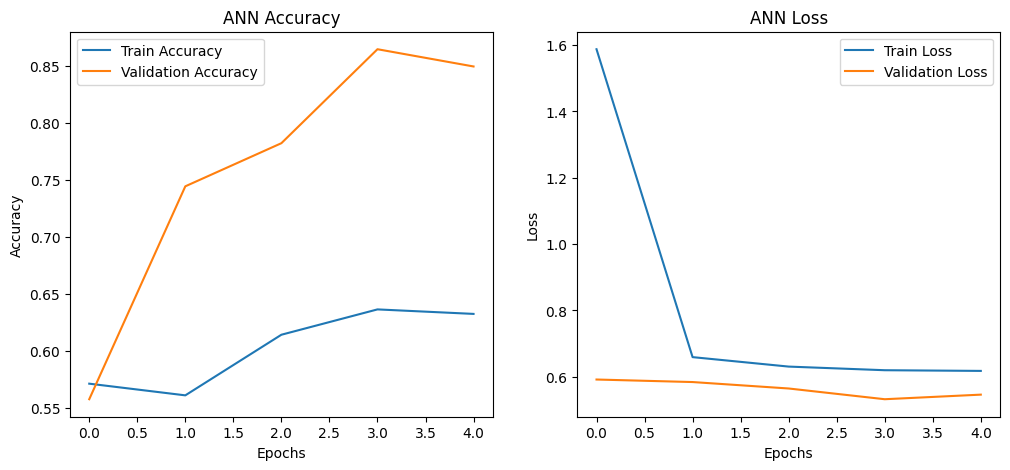

In [ ]:
# ==========================
# Plot Accuracy & Loss Curves
# ==========================
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_ann.history['accuracy'], label="Train Accuracy")
plt.plot(history_ann.history['val_accuracy'], label="Validation Accuracy")
plt.title("ANN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_ann.history['loss'], label="Train Loss")
plt.plot(history_ann.history['val_loss'], label="Validation Loss")
plt.title("ANN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Machine learning Model

In [ ]:
# ==========================
# Prepare Data for ML Models
# ==========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import cv2
import random

# Load a limited set of images for faster ML training (e.g., 3000 samples)
def load_images_ml(folder, label, n_samples=1500, img_size=(64,64)):
    data, labels = [], []
    img_files = random.sample(os.listdir(folder), min(len(os.listdir(folder)), n_samples))
    for f in img_files:
        img = cv2.imread(os.path.join(folder, f))
        if img is not None:
            img = cv2.resize(img, img_size)      # resize to smaller for ML
            img = img.flatten() / 255.0          # flatten & normalize
            data.append(img)
            labels.append(label)
    return data, labels

# Prepare dataset (small subset for speed)
X_train_O, y_train_O = load_images_ml(os.path.join(train_dir, "O"), 0)
X_train_R, y_train_R = load_images_ml(os.path.join(train_dir, "R"), 1)
X_test_O, y_test_O   = load_images_ml(os.path.join(test_dir, "O"), 0, n_samples=500)
X_test_R, y_test_R   = load_images_ml(os.path.join(test_dir, "R"), 1, n_samples=500)

# Combine
X_train = np.array(X_train_O + X_train_R)
y_train = np.array(y_train_O + y_train_R)
X_test  = np.array(X_test_O + X_test_R)
y_test  = np.array(y_test_O + y_test_R)

print("ML Dataset Shape:", X_train.shape, X_test.shape)

ML Dataset Shape: (3000, 12288) (1000, 12288)


In [ ]:
# ==========================
# Train Random Forest Classifier
# ==========================
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # allow trees to expand fully
    random_state=42,
    n_jobs=-1               # use all CPU cores for speed
)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Classification Report (ML - Random Forest):
              precision    recall  f1-score   support

     Organic       0.81      0.95      0.88       500
  Recyclable       0.94      0.78      0.85       500

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



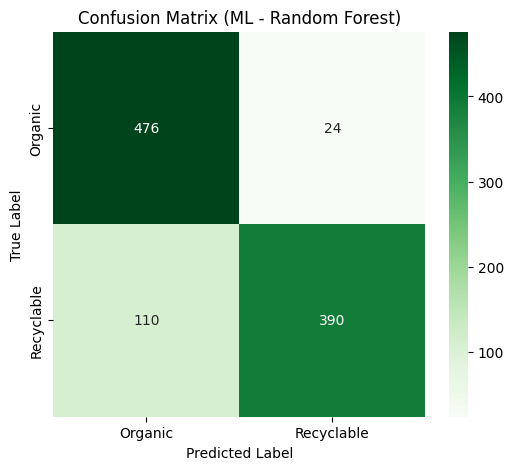

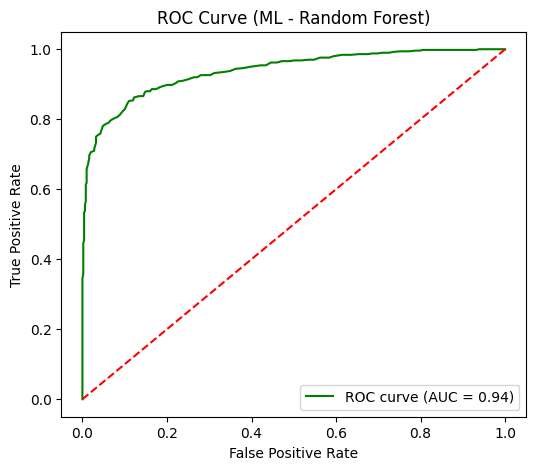

In [ ]:
# ==========================
# Evaluate Random Forest Model
# ==========================
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

# --- Classification Report ---
print("Classification Report (ML - Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=["Organic", "Recyclable"]))

# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Organic", "Recyclable"],
            yticklabels=["Organic", "Recyclable"])
plt.title("Confusion Matrix (ML - Random Forest)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- ROC Curve & AUC ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, color="green", label=f"ROC curve (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ML - Random Forest)")
plt.legend(loc="lower right")
plt.show()

# Deep learning model

In [ ]:
# ==========================
# Fast Transfer Learning Model (MobileNetV2)
# ==========================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load base model (pre-trained on ImageNet)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128,128,3))

# Freeze base model for speed
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation="softmax")(x)

model_mobilenet = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================
# Train the Model
# ==========================
EPOCHS = 5

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 168s 106ms/step - accuracy: 0.8695 - loss: 0.3109 - val_accuracy: 0.8711 - val_loss: 0.3063
Epoch 2/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 162s 88ms/step - accuracy: 0.9173 - loss: 0.2142 - val_accuracy: 0.8532 - val_loss: 0.3196
Epoch 3/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 126s 89ms/step - accuracy: 0.9274 - loss: 0.1888 - val_accuracy: 0.8552 - val_loss: 0.3096
Epoch 4/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.9295 - loss: 0.1794 - val_accuracy: 0.8392 - val_loss: 0.3852
Epoch 5/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.9303 - loss: 0.1727 - val_accuracy: 0.8945 - val_loss: 0.2879


158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step
 Classification Report (MobileNetV2):
              precision    recall  f1-score   support

           O       0.86      0.97      0.91      1401
           R       0.95      0.81      0.87      1112

    accuracy                           0.89      2513
   macro avg       0.91      0.89      0.89      2513
weighted avg       0.90      0.89      0.89      2513



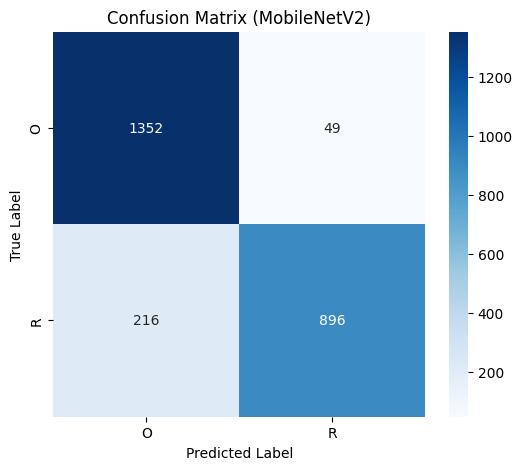

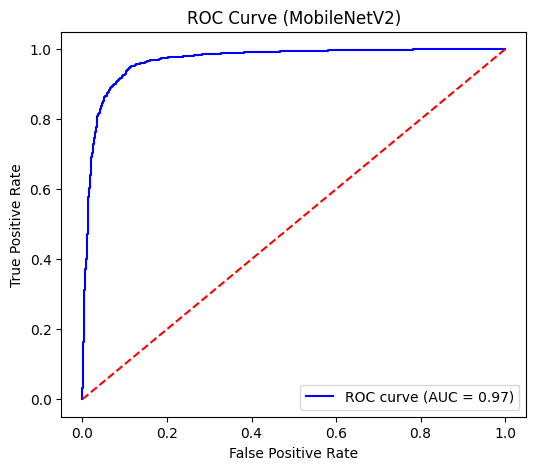

In [ ]:
# ==========================
# Evaluate the Model
# ==========================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Predictions
y_true = test_generator.classes
y_prob = model_mobilenet.predict(test_generator)
y_pred = y_prob.argmax(axis=1)

# --- Classification Report ---
print(" Classification Report (MobileNetV2):")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.title("Confusion Matrix (MobileNetV2)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# --- ROC Curve & AUC ---
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (MobileNetV2)")
plt.legend(loc="lower right")
plt.show()

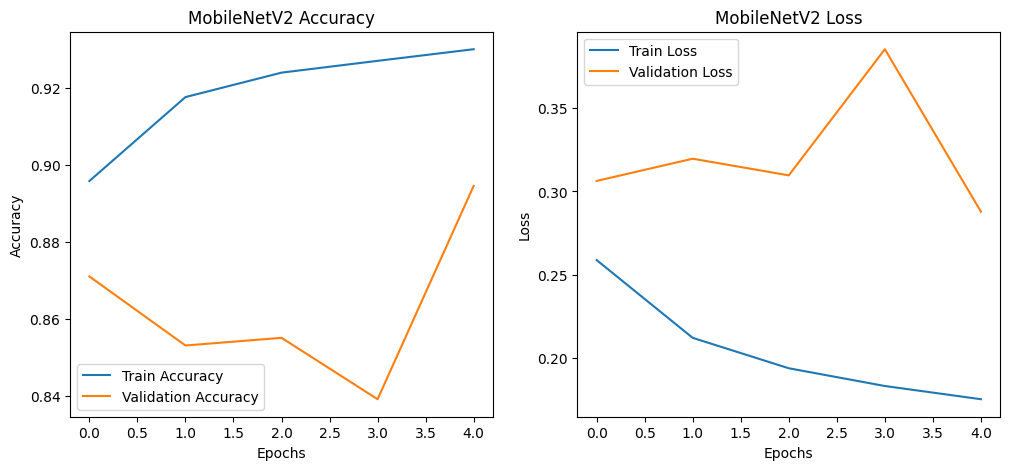

In [ ]:
# ==========================
# Plot Accuracy & Loss Curves
# ==========================
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label="Train Accuracy")
plt.plot(history_mobilenet.history['val_accuracy'], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label="Train Loss")
plt.plot(history_mobilenet.history['val_loss'], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


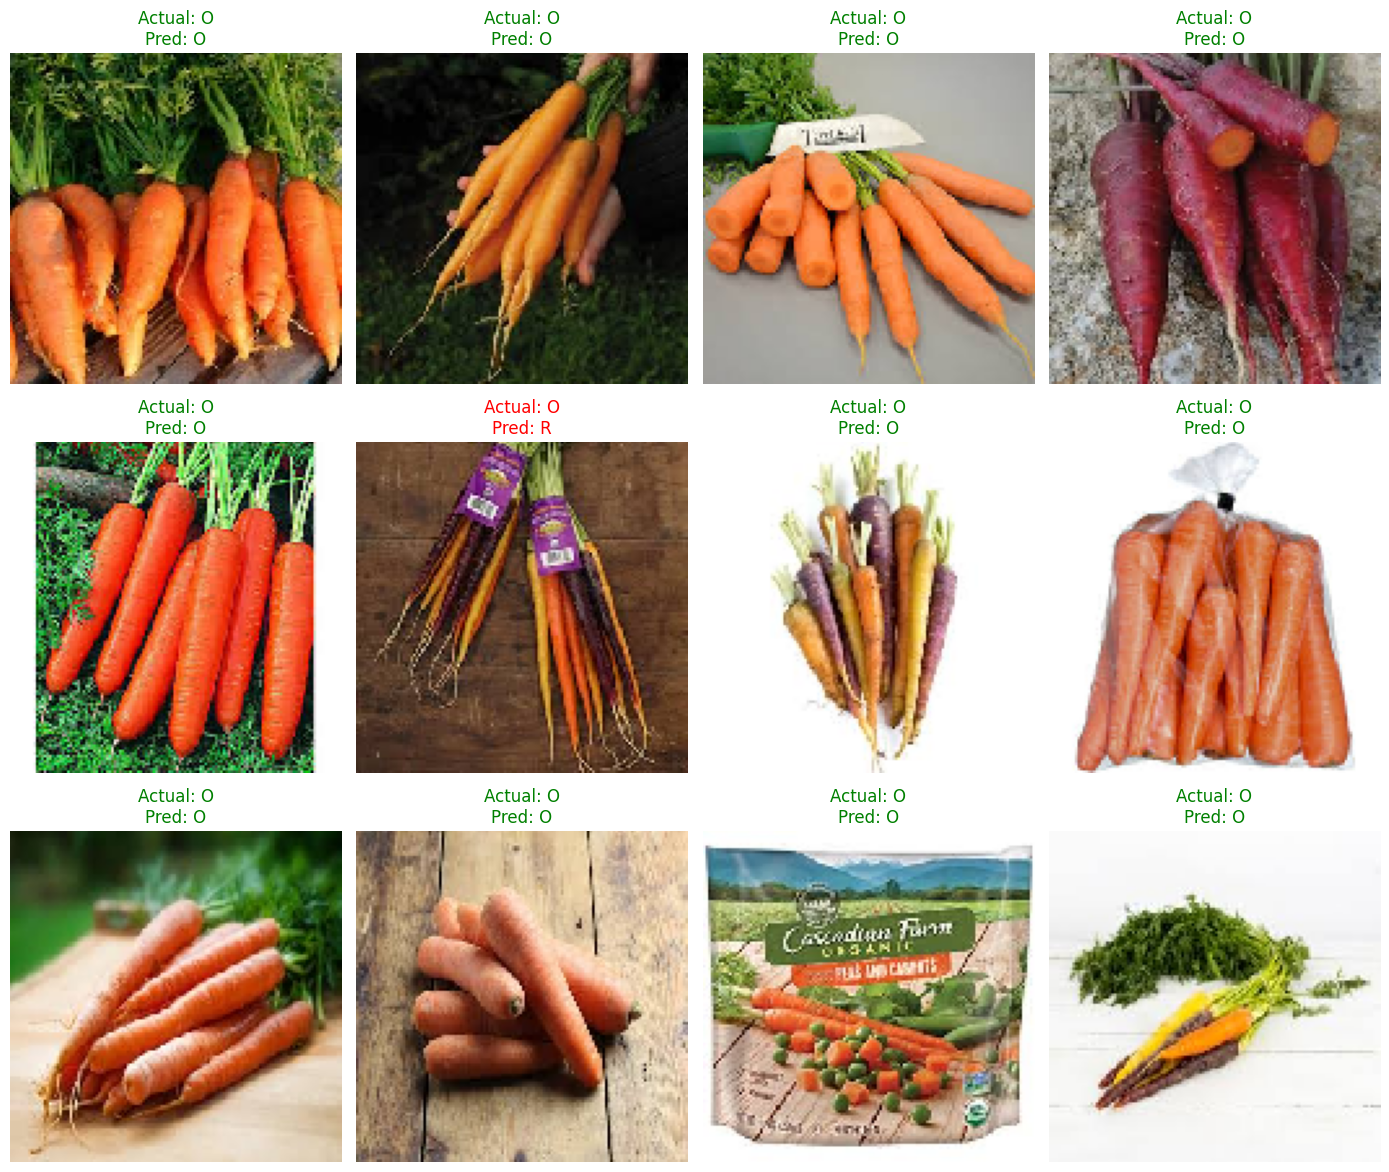

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images and labels from test set
x_batch, y_batch = next(test_generator)

# Predict using MobileNetV2
y_prob = model_mobilenet.predict(x_batch)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_batch, axis=1)

# Map class indices to labels
class_labels = list(test_generator.class_indices.keys())

# ==========================
# Plot Actual vs Predicted
# ==========================
plt.figure(figsize=(14, 12))
for i in range(12):  # show 12 images
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_batch[i])
    true_label = class_labels[y_true[i]]
    pred_label = class_labels[y_pred[i]]

    color = "green" if y_true[i] == y_pred[i] else "red"
    plt.title(f"Actual: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step


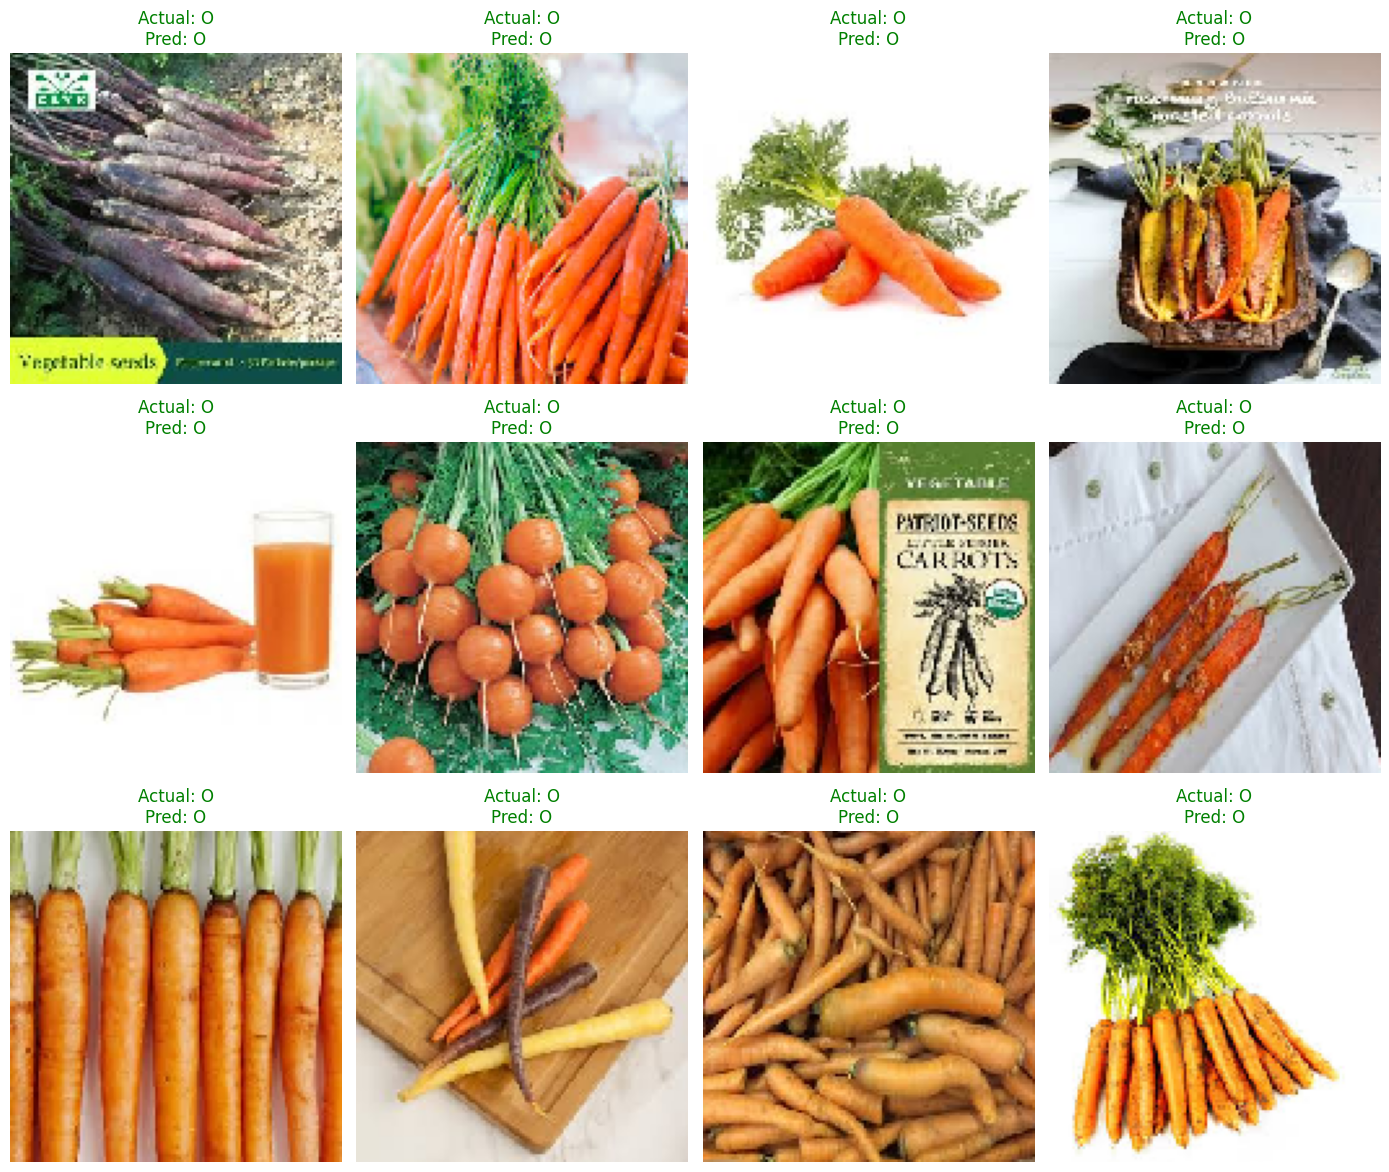

In [ ]:
# Get a batch of images and labels from test set
x_batch, y_batch = next(test_generator)

# Predict using CNN model
y_prob = model_cnn.predict(x_batch)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_batch, axis=1)

# Map class indices to labels
class_labels = list(test_generator.class_indices.keys())

# ==========================
# Plot Actual vs Predicted
# ==========================
plt.figure(figsize=(14, 12))
for i in range(12):  # show 12 images
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_batch[i])
    true_label = class_labels[y_true[i]]
    pred_label = class_labels[y_pred[i]]

    color = "green" if y_true[i] == y_pred[i] else "red"
    plt.title(f"Actual: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

# Create directory for saving models
os.makedirs("saved_models", exist_ok=True)

# ==========================
# Save Deep Learning Models
# ==========================
# CNN Model
model_cnn.save("saved_models/cnn_model.h5")

# ANN Model
model_ann.save("saved_models/ann_model.h5")

# MobileNetV2 Model
model_mobilenet.save("saved_models/mobilenetv2_model.h5")

# ==========================
# Save Machine Learning Model
# ==========================
# Random Forest
joblib.dump(rf_model, "saved_models/random_forest.pkl")

print("CNN, ANN, MobileNetV2, and Random Forest saved in 'saved_models/' folder.")

CNN, ANN, MobileNetV2, and Random Forest saved in 'saved_models/' folder.
